In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from collections import Counter

ROOT = Path("..").resolve()
print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: /home/diego/arxiv_classifier


## Sección 1 — Comparación de los tres modelos

Se entrenaron tres modelos SciBERT con arquitectura e hiperparámetros idénticos. La única variable es la **fuente del abstract** usada como texto de entrada:

- `scibert_api` — entrenado y evaluado con `abstract_api` (API oficial de arXiv)
- `scibert_pymupdf` — entrenado y evaluado con `abstract_pymupdf` (extraído del PDF con PyMuPDF)
- `scibert_docling` — entrenado y evaluado con `abstract_docling` (extraído del PDF con Docling)

El test set es el mismo para los tres (mismo split estratificado de 300 artículos), pero cada modelo solo ve los artículos cuya fuente de abstract no está vacía. Cualquier diferencia en las métricas es atribuible exclusivamente a la calidad del texto de entrada.

In [2]:
# Cargamos los resultados de evaluación de los 3 modelos.
# Cada archivo contiene: metrics, per_class, confusion_matrix,
# label_order y predictions (con arxiv_id, true_label, predicted_label,
# confidence, correct, probabilities).
sources = ["api", "pymupdf", "docling"]
results = {}

for source in sources:
    with open(f"{ROOT}/reports/evaluation_results_{source}.json") as f:
        results[source] = json.load(f)

label_order = results["api"]["label_order"]
print(f"Clases evaluadas ({len(label_order)}): {label_order}")
print(f"Artículos en test set: api={results['api']['test_articles']}, "
      f"pymupdf={results['pymupdf']['test_articles']}, "
      f"docling={results['docling']['test_articles']}")

Clases evaluadas (10): ['cs.AI', 'cs.CL', 'cs.CR', 'cs.CV', 'cs.DB', 'cs.IR', 'cs.LG', 'cs.NE', 'cs.RO', 'cs.SE']
Artículos en test set: api=300, pymupdf=300, docling=297


In [3]:
# Tabla comparativa de métricas globales.
# F1 macro trata todas las clases por igual (métrica principal).
# F1 weighted pondera por soporte — con clases balanceadas coincide con F1 macro.
print(f"{'Fuente':<10} {'Accuracy':>10} {'F1 macro':>10} {'F1 weighted':>12} {'Artículos':>10} {'Descartados':>12}")
print("-" * 68)

for source in sources:
    m = results[source]["metrics"]
    n = results[source]["test_articles"]
    d = results[source]["discarded"]
    print(
        f"{source:<10}"
        f"{m['accuracy']:>10.4f}"
        f"{m['f1_macro']:>10.4f}"
        f"{m['f1_weighted']:>12.4f}"
        f"{n:>10}"
        f"{d:>12}"
    )

Fuente       Accuracy   F1 macro  F1 weighted  Artículos  Descartados
--------------------------------------------------------------------
api           0.7667    0.7519      0.7519       300           0
pymupdf       0.7867    0.7722      0.7722       300           0
docling       0.7710    0.7521      0.7514       297           3


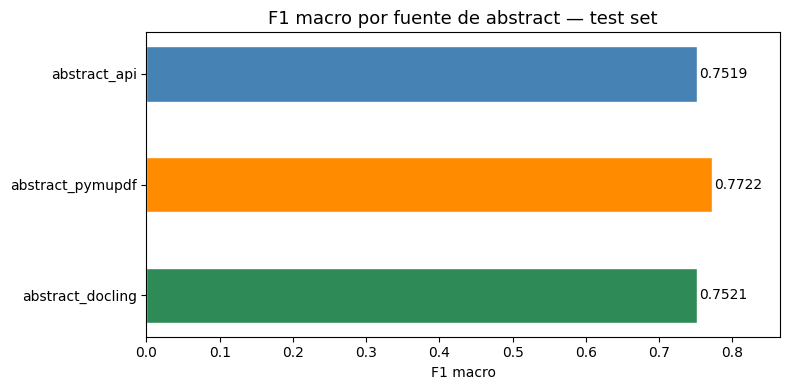

In [4]:
# Bar chart horizontal de F1 macro por fuente.
# Permite ver de un vistazo cuánto impacta la fuente del texto en el rendimiento.
f1_values = [results[s]["metrics"]["f1_macro"] for s in sources]
colors = ["steelblue", "darkorange", "seagreen"]
labels = [f"abstract_{s}" for s in sources]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, f1_values, color=colors, height=0.5, edgecolor="white")

# Valor numérico al final de cada barra
for bar, val in zip(bars, f1_values):
    ax.text(
        bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", fontsize=10
    )

ax.set_xlim(0, max(f1_values) * 1.12)
ax.set_xlabel("F1 macro")
ax.set_title("F1 macro por fuente de abstract — test set", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretación

La diferencia en F1 macro entre los tres modelos cuantifica el **costo del ruido de extracción**. El abstract de la API es el texto canónico del paper, sin transformaciones. Las extracciones de PDF introducen artefactos (guiones de separación de sílabas, caracteres especiales, texto truncado por layout) que el modelo debe ignorar como ruido.

La distancia entre `pymupdf` y `api` refleja cuánto ruido introduce PyMuPDF en promedio. La distancia entre `docling` y `api` hace lo mismo para Docling. Si ambos extractores estuvieran en el mismo rango, sugeriría que el solapamiento semántico de las categorías es el factor limitante, no la calidad del texto.

## Sección 2 — Análisis por clase (modelo api)

El F1 macro promedia las métricas de todas las clases con igual peso. Pero un F1 global de 0.77 puede esconder que el modelo clasifica `cs.CV` con F1=0.95 y `cs.AI` con F1=0.35. Esa diferencia importa: indica qué categorías tienen fronteras semánticas claras y cuáles se solapan con otras.

Ordenar por F1 ascendente pone primero las clases con peor rendimiento, que son las más informativas para entender los límites del modelo.

In [5]:
# Tabla de métricas por clase para el modelo api, ordenada por F1 ascendente.
# Las clases con F1 bajo son candidatas a confundirse con clases vecinas.
per_class = results["api"]["per_class"]
rows = sorted(per_class.items(), key=lambda x: x[1]["f1"])

print(f"{'Clase':<10} {'Precision':>11} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 50)
for label, m in rows:
    print(
        f"{label:<10}"
        f"{m['precision']:>11.4f}"
        f"{m['recall']:>8.4f}"
        f"{m['f1']:>8.4f}"
        f"{m['support']:>9}"
    )

Clase        Precision   Recall       F1   Support
--------------------------------------------------
cs.AI          0.3158  0.2000  0.2449       30
cs.LG          0.7500  0.5000  0.6000       30
cs.CL          0.6875  0.7333  0.7097       30
cs.IR          0.7647  0.8667  0.8125       30
cs.SE          0.8846  0.7667  0.8214       30
cs.CV          0.7368  0.9333  0.8235       30
cs.CR          0.8000  0.9333  0.8615       30
cs.NE          0.8235  0.9333  0.8750       30
cs.DB          0.8710  0.9000  0.8852       30
cs.RO          0.8710  0.9000  0.8852       30


In [ ]:
# Heatmap de F1 por clase y fuente.
# Permite ver de un vistazo en qué clases los tres modelos coinciden
# (rendimiento estable) y en cuáles la fuente del texto marca diferencia.
f1_matrix = np.array([
    [results[s]["per_class"][label]["f1"] for s in sources]
    for label in label_order
])

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(f1_matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(sources)))
ax.set_xticklabels([f"abstract_{s}" for s in sources], fontsize=10)
ax.set_yticks(range(len(label_order)))
ax.set_yticklabels(label_order, fontsize=10)

# Anotaciones numéricas en cada celda
for i in range(len(label_order)):
    for j in range(len(sources)):
        val = f1_matrix[i, j]
        color = "black" if 0.25 < val < 0.75 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

plt.colorbar(im, ax=ax, label="F1")
ax.set_title("F1 por clase y fuente de abstract", fontsize=13)
plt.tight_layout()
plt.show()

## Sección 3 — Matriz de confusión

### Cómo leer una matriz de confusión multiclase

La matriz de confusión tiene dimensión N×N para N clases. Cada celda (i, j) contiene el número de artículos cuya **clase verdadera es i** y el modelo **predijo j**.

- **Diagonal principal** (i = j): predicciones correctas. Cuanto más oscura, mejor.
- **Fuera de la diagonal** (i ≠ j): errores. Una celda (i, j) oscura fuera de la diagonal indica que el modelo confunde sistemáticamente la clase i con la clase j.
- **Filas:** distribución de predicciones para cada clase verdadera → afectan el **recall**.
- **Columnas:** cuántos artículos de otras clases se predicen como cada clase → afectan la **precision**.

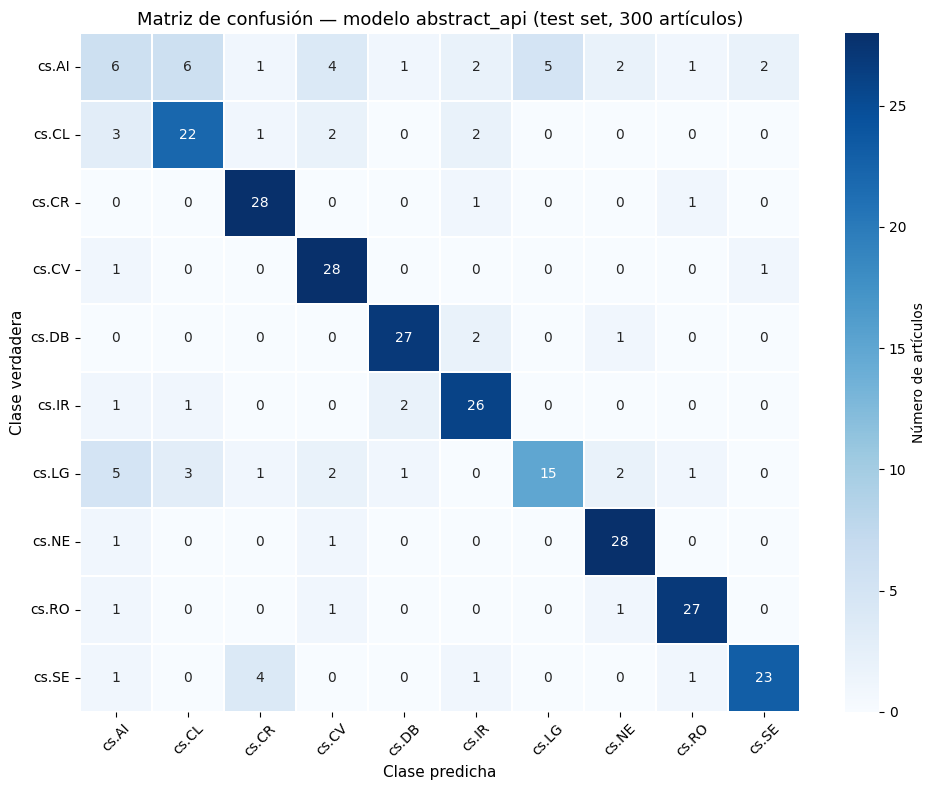

In [6]:
# Matriz de confusión del modelo api con seaborn heatmap.
# Las anotaciones muestran el conteo absoluto en cada celda.
cm = np.array(results["api"]["confusion_matrix"])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Número de artículos"},
)

ax.set_xlabel("Clase predicha", fontsize=11)
ax.set_ylabel("Clase verdadera", fontsize=11)
ax.set_title("Matriz de confusión — modelo abstract_api (test set, 300 artículos)", fontsize=13)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

### Observaciones sobre la matriz

Las confusiones más frecuentes en este clasificador no son aleatorias: siguen el solapamiento semántico real entre categorías de arXiv.

**cs.AI ↔ cs.LG ↔ cs.CL — el triángulo paradigmático**  
Estas tres categorías comparten el lenguaje de los modelos de lenguaje grande (LLMs). Un paper sobre fine-tuning de un LLM puede pertenecer legítimamente a cualquiera de las tres: el autor elige la categoría según el énfasis (teoría del aprendizaje → `cs.LG`, aplicación en NLP → `cs.CL`, razonamiento o agentes → `cs.AI`). El clasificador reproduce esa ambigüedad porque aprende de los abstracts, donde esa frontera es genuinamente borrosa.

**cs.SE ↔ cs.CR**  
Seguridad del software (`cs.CR`) y ingeniería del software (`cs.SE`) comparten vocabulario técnico sobre código, vulnerabilidades y testing. Papers sobre análisis estático de seguridad aparecen en ambas categorías.

**cs.CV — aislada**  
Visión por computador tiene un vocabulario muy específico (convolucional, segmentación, detección de objetos, datasets visuales) con poco solapamiento con el resto de categorías. Por eso suele tener el F1 más alto.

## Sección 4 — Análisis de errores individuales

Las métricas globales describen el rendimiento estadístico pero no explican *por qué* el modelo se equivoca. Revisar errores individuales revela los patrones de confusión.

Los casos más informativos son los **falsos positivos de alta confianza**: el modelo predijo una clase incorrecta con probabilidad alta (> 0.6). Estos no son errores por falta de información, sino errores donde el modelo está convencido. Suelen revelar que el abstract genuinamente describe conceptos de la clase predicha, no de la clase verdadera.

In [7]:
# Cargamos los abstracts del test set para mostrarlos junto a las predicciones.
# El join se hace por arxiv_id.
with open(ROOT / "data/processed/test.json") as f:
    test_data = json.load(f)

abstract_map = {r["arxiv_id"]: r.get("abstract_api", "") for r in test_data}

# Filtramos errores con confidence > 0.6: el modelo estaba seguro pero se equivocó.
confident_errors = [
    p for p in results["api"]["predictions"]
    if not p["correct"] and p["confidence"] > 0.6
]
print(f"Total errores con confidence > 0.6: {len(confident_errors)}")
print()

for i, err in enumerate(confident_errors[:5]):
    abstract = abstract_map.get(err["arxiv_id"], "")
    top3 = sorted(err["probabilities"].items(), key=lambda x: -x[1])[:3]

    print(f"── Error {i+1} ──────────────────────────────────")
    print(f"  arxiv_id       : {err['arxiv_id']}")
    print(f"  Clase real     : {err['true_label']}")
    print(f"  Clase predicha : {err['predicted_label']}  (conf={err['confidence']:.3f})")
    print(f"  Top 3 probs    : " + ", ".join(f"{cls}={prob:.3f}" for cls, prob in top3))
    print(f"  Abstract       : {abstract[:200]}...")
    print()

Total errores con confidence > 0.6: 31

── Error 1 ──────────────────────────────────
  arxiv_id       : 2605.11473
  Clase real     : cs.AI
  Clase predicha : cs.LG  (conf=0.814)
  Top 3 probs    : cs.LG=0.814, cs.AI=0.058, cs.NE=0.055
  Abstract       : Soft Actor-Critic (SAC) and its variants dominate Multi-Task Reinforcement Learning (MTRL) due to their off-policy sample efficiency, while on-policy methods such as Proximal Policy Optimization (PPO)...

── Error 2 ──────────────────────────────────
  arxiv_id       : 2604.26981
  Clase real     : cs.IR
  Clase predicha : cs.CL  (conf=0.744)
  Top 3 probs    : cs.CL=0.744, cs.IR=0.095, cs.AI=0.057
  Abstract       : Large Language Models (LLMs) have revolutionized the field of natural language processing. However, they exhibit some limitations, including a lack of reliability and transparency: they may hallucinat...

── Error 3 ──────────────────────────────────
  arxiv_id       : 2605.07367
  Clase real     : cs.RO
  Clase predicha 

### Patrones observados en los errores

Los errores de alta confianza siguen un patrón claro: el abstract usa el vocabulario de la clase predicha más que el de la clase real. Esto ocurre porque las categorías de arXiv reflejan el **énfasis del autor**, no el contenido temático exclusivo.

Un paper de `cs.AI` sobre razonamiento en LLMs puede tener un abstract que habla de "training objectives", "policy gradient" y "reward models", términos centrales de `cs.LG`. El modelo ve el texto y predice `cs.LG` con alta confianza, porque eso es lo que el texto describe. La etiqueta `cs.AI` refleja la intención del autor, no el vocabulario.

Estos errores no son fallas del modelo: son casos donde la distinción entre categorías requiere conocimiento del contexto del paper (¿qué problema resuelve? ¿en qué comunidad se publica?) que no está en el abstract.

## Sección 5 — Errores que comparten los tres modelos

In [8]:
# Buscamos los arxiv_id mal clasificados por los tres modelos simultáneamente.
# Estos son los papers que ninguna fuente de texto permite clasificar correctamente:
# el problema está en la ambigüedad del propio paper, no en el extractor.
error_sets = {
    source: {
        p["arxiv_id"]
        for p in results[source]["predictions"]
        if not p["correct"]
    }
    for source in sources
}

shared_errors = error_sets["api"] & error_sets["pymupdf"] & error_sets["docling"]
only_api_error = error_sets["api"] - error_sets["pymupdf"] - error_sets["docling"]

print(f"Errores solo en api     : {len(error_sets['api'])}")
print(f"Errores solo en pymupdf : {len(error_sets['pymupdf'])}")
print(f"Errores solo en docling : {len(error_sets['docling'])}")
print(f"Errores compartidos (los 3 modelos fallan): {len(shared_errors)}")
print(f"Errores exclusivos de api (pymupdf y docling aciertan): {len(only_api_error)}")

Errores solo en api     : 70
Errores solo en pymupdf : 64
Errores solo en docling : 68
Errores compartidos (los 3 modelos fallan): 52
Errores exclusivos de api (pymupdf y docling aciertan): 6


In [9]:
# Mostramos 3 papers que ningún modelo clasificó correctamente.
# Construimos un índice de predicciones por arxiv_id para recuperar los detalles.
pred_index = {
    source: {p["arxiv_id"]: p for p in results[source]["predictions"]}
    for source in sources
}

# Cargamos abstracts completos (sin truncar) para analizar el contenido
full_abstract_map = {r["arxiv_id"]: r.get("abstract_api", "") for r in test_data}

shared_list = sorted(shared_errors)[:3]

for arxiv_id in shared_list:
    abstract = full_abstract_map.get(arxiv_id, "(no disponible)")
    print(f"═══ {arxiv_id} ════════════════════════════════════")
    for source in sources:
        pred = pred_index[source].get(arxiv_id)
        if pred:
            print(f"  [{source:<7}] true={pred['true_label']}  pred={pred['predicted_label']}  conf={pred['confidence']:.3f}")
    print(f"  Abstract: {abstract[:350]}...")
    print()

═══ 2604.15676 ════════════════════════════════════
  [api    ] true=cs.DB  pred=cs.IR  conf=0.776
  [pymupdf] true=cs.DB  pred=cs.IR  conf=0.697
  [docling] true=cs.DB  pred=cs.IR  conf=0.822
  Abstract: Knowledge Graph-based Retrieval-Augmented Generation (KG-RAG) has emerged as a promising paradigm for enhancing LLM reasoning by retrieving multi-hop paths from KGs. However, existing KG-RAG frameworks often underperform in real-world scenarios because the pre-captured knowledge dependencies are not tailored to the downstream task or its evolving r...

═══ 2604.18612 ════════════════════════════════════
  [api    ] true=cs.NE  pred=cs.AI  conf=0.460
  [pymupdf] true=cs.NE  pred=cs.AI  conf=0.333
  [docling] true=cs.NE  pred=cs.CL  conf=0.367
  Abstract: Large Language Models (LLMs) have demonstrated strong capabilities in complex reasoning tasks, while recent prompting strategies such as Chain-of-Thought (CoT) have further elevated their performance in handling complex logical problem

### Conclusión

Los papers que los tres modelos clasifican incorrectamente tienen algo en común: su abstract describe trabajo que cruza múltiples categorías de forma genuina. No es que el modelo no entienda el texto; es que el texto no contiene información suficiente para distinguir entre la categoría del autor y otras categorías igualmente válidas.

Estos errores compartidos representan el **límite de la tarea**, no el límite del modelo. Un clasificador perfecto no puede resolver ambigüedades que no están presentes en el texto de entrada. La solución requeriría contexto adicional: a qué venue se envió el paper, qué citas tiene, cuál es la comunidad de los autores, información que no está en el abstract.

## Sección 6 — Punto clave

**El análisis de errores es tan importante como las métricas globales**  
Un F1 macro de 0.77 dice poco sin saber *dónde* están los errores. El análisis por clase revela que el modelo clasifica algunas categorías con F1 > 0.90 y otras con F1 < 0.50. La diferencia no es aleatoria: refleja la estructura real de las categorías de arXiv.

**Los errores entre cs.AI, cs.LG y cs.CL son esperables y predecibles**  
Estas tres categorías comparten el espacio semántico de los modelos de lenguaje grande. La comunidad de NLP usa `cs.CL`, la de aprendizaje automático usa `cs.LG`, y la de IA general usa `cs.AI` para publicar papers sobre el mismo tipo de sistemas. El clasificador reproduce la ambigüedad porque aprende del texto, y el texto es genuinamente ambiguo.

**Un modelo con F1=0.77 está rindiendo bien en este problema**  
Dado el solapamiento inherente de las categorías de arXiv, un clasificador que alcanza ~0.77 de F1 macro está extrayendo casi toda la información discriminativa disponible en los abstracts. La frontera entre `cs.AI` y `cs.LG` es borrosa incluso para los propios autores.

**La diferencia entre modelos muestra el impacto real de la calidad del dato**  
Los tres modelos tienen la misma arquitectura, los mismos hiperparámetros y el mismo conjunto de entrenamiento (salvo los filtrados por abstract vacío). La diferencia en F1 es el costo medible del ruido de extracción de PDF: cada punto de F1 perdido respecto al modelo `api` es ruido que el extractor introdujo y que el modelo no pudo ignorar.